<a href="https://colab.research.google.com/github/froz-zi/ML/blob/main/Randomforest/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

In [8]:
df = pd.read_csv('Social_Network_Ads.csv')
print("5 baris pertama dataset:")
print(df.head())

5 baris pertama dataset:
    User ID  Age  EstimatedSalary  Purchased
0  15624510   19            19000          0
1  15810944   35            20000          0
2  15668575   26            43000          0
3  15603246   27            57000          0
4  15804002   19            76000          0


In [9]:
print("\nInfo dataset:")
print(df.info())


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB
None


In [10]:
# X = input yang digunakan untuk prediksi
# y = apa yang ingin kita prediksi (Purchased: 0 atau 1)
# ----------------------------------------------------------
X = df[['Age', 'EstimatedSalary']].values   # Fitur: Umur & Gaji
y = df['Purchased'].values                   # Target: Beli atau Tidak

print(f"\nJumlah data: {len(X)} baris")
print(f"Distribusi kelas:\n{pd.Series(y).value_counts()}")


Jumlah data: 400 baris
Distribusi kelas:
0    257
1    143
Name: count, dtype: int64


In [11]:
# 4. SPLIT DATA: TRAIN & TEST (test_size=0.25)
# 75% data untuk melatih model, 25% untuk menguji
# random_state=0 agar hasil bisa direproduksi
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # 25% untuk test
    random_state=0       # seed agar hasilnya konsisten
)

print(f"\nJumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}")


Jumlah data training : 300
Jumlah data testing  : 100


In [12]:
# 5. FEATURE SCALING (Standarisasi)
# Mengubah skala fitur agar memiliki mean=0, std=1
# Penting agar fitur dengan nilai besar tidak mendominasi
# ----------------------------------------------------------
sc = StandardScaler()
X_train = sc.fit_transform(X_train)   # fit HANYA di data training
X_test  = sc.transform(X_test)

In [15]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)

In [16]:
classifier = DecisionTreeClassifier(
    criterion='entropy',   # metode pengukuran impurity
    random_state=0         # seed untuk konsistensi
)
classifier.fit(X_train, y_train)   # latih model dengan data training

print("\nModel berhasil dilatih!")
print(f"Kedalaman pohon: {classifier.get_depth()}")
print(f"Jumlah daun    : {classifier.get_n_leaves()}")


Model berhasil dilatih!
Kedalaman pohon: 12
Jumlah daun    : 50


In [18]:
y_pred = classifier.predict(X_test)

# Contoh perbandingan prediksi vs nilai asli
print("\nPerbandingan prediksi vs aktual (10 data pertama):")
print(f"Prediksi : {y_pred[:100]}")
print(f"Aktual   : {y_test[:100]}")



Perbandingan prediksi vs aktual (10 data pertama):
Prediksi : [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 1 0 0 1
 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 1 1]
Aktual   : [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]


In [20]:
# 8. EVALUASI MODEL
# Confusion Matrix: tabel yang menunjukkan seberapa akurat prediksi
# Accuracy: persentase prediksi yang benar
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"\nConfusion Matrix:\n{cm}")
print(f"\nAkurasi Model: {acc * 100:.2f}%")


Confusion Matrix:
[[62  6]
 [ 3 29]]

Akurasi Model: 91.00%


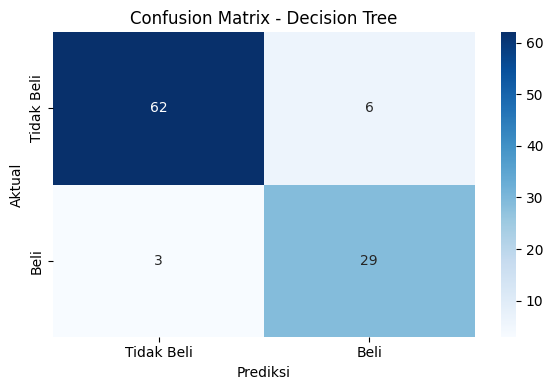

In [21]:
# 9. VISUALISASI CONFUSION MATRIX
# Heatmap agar mudah dibaca
# ----------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Beli', 'Beli'],
            yticklabels=['Tidak Beli', 'Beli'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

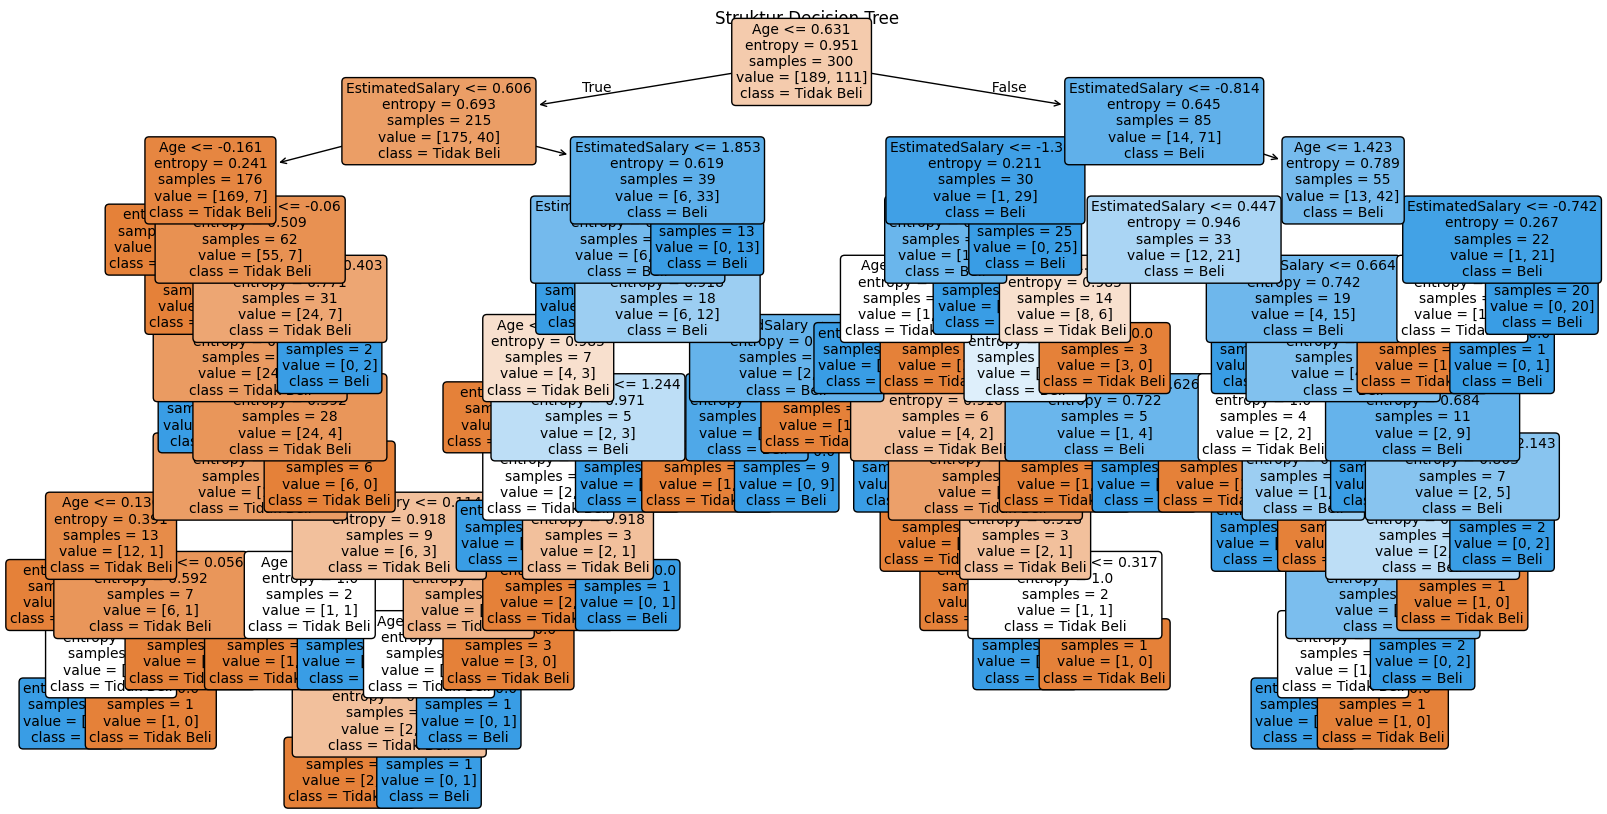

In [23]:
# 10. VISUALISASI POHON KEPUTUSAN
# Melihat struktur pohon yang terbentuk
plt.figure(figsize=(20, 10))
plot_tree(
    classifier,
    feature_names=['Age', 'EstimatedSalary'],
    class_names=['Tidak Beli', 'Beli'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Struktur Decision Tree')
plt.show()

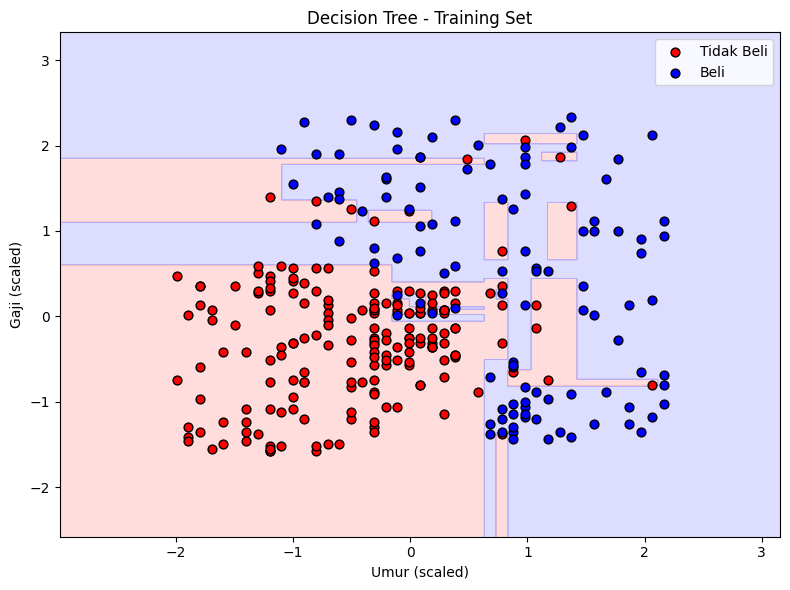

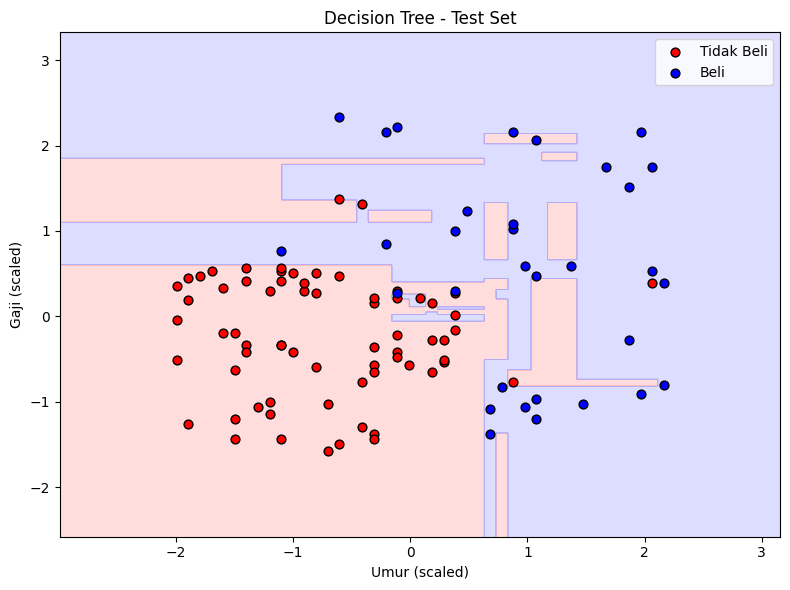

In [24]:
# 11. VISUALISASI DECISION BOUNDARY (Training Set)
# Menampilkan batas keputusan model pada data training
# ----------------------------------------------------------
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, classifier, title):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(
        np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
        np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
    )
    Z = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(X1, X2, Z, alpha=0.4, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1],
                c='red', label='Tidak Beli', edgecolors='k', s=40)
    plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1],
                c='blue', label='Beli', edgecolors='k', s=40)
    plt.title(title)
    plt.xlabel('Umur (scaled)')
    plt.ylabel('Gaji (scaled)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot untuk Training Set
plot_decision_boundary(X_train, y_train, classifier,
                       'Decision Tree - Training Set')

# Plot untuk Test Set
plot_decision_boundary(X_test, y_test, classifier,
                       'Decision Tree - Test Set')